In [1]:
# =============================================================================
# SECTION 1: IMPORTS
# =============================================================================
import os, json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, Model

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))


# =============================================================================
# SECTION 2: PATHS
# =============================================================================
SRC_BASE = "/kaggle/input/datasets/kavyagupta3011/vr-dataset-deepfashion2/pruned_deepfashion2/final_dataset"

SRC_TRAIN_IMG = os.path.join(SRC_BASE, "train", "images")
SRC_TRAIN_ANN = os.path.join(SRC_BASE, "train", "annotations")
SRC_VAL_IMG   = os.path.join(SRC_BASE, "val", "images")
SRC_VAL_ANN   = os.path.join(SRC_BASE, "val", "annotations")


# =============================================================================
# SECTION 3: LABEL MAP
# =============================================================================
LABEL_MAP = {
    "short sleeve top": 0,
    "trousers": 1,
    "shorts": 2,
    "long sleeve top": 3,
    "skirt": 4
}

top5 = [1, 8, 7, 2, 9]
cat_to_index = {1:0, 8:1, 7:2, 2:3, 9:4}
num_classes = 5


# =============================================================================
# SECTION 4: SPLIT
# =============================================================================
def split_train_folder(val_size=0.2):
    valid, labels = [], []
    for ann in os.listdir(SRC_TRAIN_ANN):
        if not ann.endswith(".json"): continue
        img = ann.replace(".json",".jpg")
        if not os.path.exists(os.path.join(SRC_TRAIN_IMG,img)): continue

        data = json.load(open(os.path.join(SRC_TRAIN_ANN,ann)))
        cats = [v["category_id"] for v in data.values()
                if isinstance(v,dict) and v.get("category_id") in top5]

        if not cats: continue

        valid.append(img)
        labels.append(max(set(cats), key=cats.count))

    return train_test_split(valid, test_size=val_size,
                            stratify=labels, random_state=42)

train_files, val_files = split_train_folder()


# =============================================================================
# SECTION 5: CLASS WEIGHTS
# =============================================================================
def compute_class_weights(files):
    labels=[]
    for f in files:
        data=json.load(open(os.path.join(SRC_TRAIN_ANN,f.replace(".jpg",".json"))))
        vec=np.zeros(num_classes)

        for v in data.values():
            if isinstance(v,dict) and v.get("category_id") in top5:
                vec[cat_to_index[v["category_id"]]]=1

        labels.append(vec)

    labels=np.array(labels)
    counts=labels.sum(0)
    total=counts.sum()

    return {i:float(total/(num_classes*c)) for i,c in enumerate(counts)}

class_weights = compute_class_weights(train_files)


# =============================================================================
# SECTION 6: CONFIG (SAFE)
# =============================================================================
IMG_SIZE = 224
BATCH_SIZE = 32

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")


# =============================================================================
# SECTION 7: AUGMENTATION
# =============================================================================
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
])


# =============================================================================
# SECTION 8: LABEL BUILDER
# =============================================================================
def build_label(path):
    data = json.load(open(path))
    vec = np.zeros(num_classes)

    for v in data.values():
        if isinstance(v, dict) and v.get("category_id") in top5:
            vec[cat_to_index[v["category_id"]]] = 1

    return vec.astype(np.float32)


# =============================================================================
# SECTION 9: DATASET
# =============================================================================
def create_dataset(files,img_dir,ann_dir,augment=False):
    def gen():
        for f in files:
            img = np.array(Image.open(os.path.join(img_dir,f)).resize((IMG_SIZE,IMG_SIZE)))
            label = build_label(os.path.join(ann_dir,f.replace(".jpg",".json")))
            yield img.astype(np.float32), label

    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec((IMG_SIZE,IMG_SIZE,3),tf.float32),
            tf.TensorSpec((num_classes,),tf.float32)
        )
    )

    if augment:
        ds = ds.map(lambda x,y:(data_aug(x,training=True),y),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.shuffle(1024)

    ds = ds.map(lambda x,y:(preprocess_input(x),y),
                num_parallel_calls=tf.data.AUTOTUNE)

    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_ds = create_dataset(train_files,SRC_TRAIN_IMG,SRC_TRAIN_ANN,True)
val_ds   = create_dataset(val_files,SRC_TRAIN_IMG,SRC_TRAIN_ANN,False)



2026-03-25 06:24:25.147339: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774419865.375833      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774419865.437674      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774419865.911710      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774419865.911759      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774419865.911761      55 computation_placer.cc:177] computation placer alr

2.19.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


I0000 00:00:1774421556.807994      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774421556.814400      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [2]:
# =============================================================================
# SECTION 10: MODEL
# =============================================================================
def build_model(strategy="transfer"):
    if strategy=="transfer":
        base = ResNet50(weights="imagenet", include_top=False,
                        input_shape=(IMG_SIZE,IMG_SIZE,3))
        base.trainable=False
    else:
        base = ResNet50(weights=None, include_top=False,
                        input_shape=(IMG_SIZE,IMG_SIZE,3))
        base.trainable=True

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512,activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256,activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes,activation="sigmoid",dtype="float32")(x)

    model = Model(base.input,out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="binary_crossentropy",
        metrics=["binary_accuracy"]
    )
    return model


# =============================================================================
# SECTION 11: TRAIN TRANSFER
# =============================================================================
model_t = build_model("transfer")

train_ds_rep = train_ds.repeat()
steps_per_epoch = max(1, len(train_files)//BATCH_SIZE)

history_t = model_t.fit(
    train_ds_rep,
    validation_data=val_ds,
    epochs=8,
    steps_per_epoch=steps_per_epoch,
    class_weight=class_weights
)



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8


I0000 00:00:1774421655.679716     136 service.cc:152] XLA service 0x7fabd8006000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774421655.679765     136 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774421655.679771     136 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774421658.179685     136 cuda_dnn.cc:529] Loaded cuDNN version 91002


   3/3604 ━━━━━━━━━━━━━━━━━━━━ 2:24 40ms/step - binary_accuracy: 0.4747 - loss: 0.9215   

I0000 00:00:1774421665.887887     136 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3604/3604 ━━━━━━━━━━━━━━━━━━━━ 3112s 853ms/step - binary_accuracy: 0.7158 - loss: 0.4992 - val_binary_accuracy: 0.7959 - val_loss: 0.4297
Epoch 2/8


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


3604/3604 ━━━━━━━━━━━━━━━━━━━━ 2089s 578ms/step - binary_accuracy: 0.7770 - loss: 0.4006 - val_binary_accuracy: 0.8124 - val_loss: 0.4032
Epoch 3/8
3604/3604 ━━━━━━━━━━━━━━━━━━━━ 2039s 566ms/step - binary_accuracy: 0.7900 - loss: 0.3812 - val_binary_accuracy: 0.8188 - val_loss: 0.3910
Epoch 4/8
3604/3604 ━━━━━━━━━━━━━━━━━━━━ 2117s 588ms/step - binary_accuracy: 0.7975 - loss: 0.3690 - val_binary_accuracy: 0.8233 - val_loss: 0.3821
Epoch 5/8
3604/3604 ━━━━━━━━━━━━━━━━━━━━ 2097s 582ms/step - binary_accuracy: 0.8027 - loss: 0.3602 - val_binary_accuracy: 0.8282 - val_loss: 0.3750
Epoch 6/8
3604/3604 ━━━━━━━━━━━━━━━━━━━━ 2022s 561ms/step - binary_accuracy: 0.8063 - loss: 0.3542 - val_binary_accuracy: 0.8301 - val_loss: 0.3695
Epoch 7/8
3604/3604 ━━━━━━━━━━━━━━━━━━━━ 2030s 563ms/step - binary_accuracy: 0.8100 - loss: 0.3481 - val_binary_accuracy: 0.8322 - val_loss: 0.3661
Epoch 8/8
3604/3604 ━━━━━━━━━━━━━━━━━━━━ 2014s 559ms/step - binary_accuracy: 0.8136 - loss: 0.3430 - val_binary_accuracy: 

In [3]:
# =============================================================================
# SECTION 12: TRAIN SCRATCH
# =============================================================================
model_s = build_model("scratch")

history_s = model_s.fit(
    train_ds_rep,
    validation_data=val_ds,
    epochs=8,
    steps_per_epoch=steps_per_epoch,
    class_weight=class_weights
)


Epoch 1/8
3604/3604 ━━━━━━━━━━━━━━━━━━━━ 2331s 621ms/step - binary_accuracy: 0.6632 - loss: 0.5724 - val_binary_accuracy: 0.7099 - val_loss: 0.5744
Epoch 2/8
3604/3604 ━━━━━━━━━━━━━━━━━━━━ 2275s 620ms/step - binary_accuracy: 0.7134 - loss: 0.4923 - val_binary_accuracy: 0.6729 - val_loss: 1.2519
Epoch 3/8
3604/3604 ━━━━━━━━━━━━━━━━━━━━ 2271s 630ms/step - binary_accuracy: 0.7316 - loss: 0.4702 - val_binary_accuracy: 0.7490 - val_loss: 0.5035
Epoch 4/8
3604/3604 ━━━━━━━━━━━━━━━━━━━━ 2352s 653ms/step - binary_accuracy: 0.7568 - loss: 0.4317 - val_binary_accuracy: 0.7908 - val_loss: 0.4415
Epoch 5/8
3604/3604 ━━━━━━━━━━━━━━━━━━━━ 2410s 669ms/step - binary_accuracy: 0.7851 - loss: 0.3964 - val_binary_accuracy: 0.8114 - val_loss: 0.4061
Epoch 6/8
3604/3604 ━━━━━━━━━━━━━━━━━━━━ 2367s 657ms/step - binary_accuracy: 0.8055 - loss: 0.3677 - val_binary_accuracy: 0.8106 - val_loss: 0.4057
Epoch 7/8
3604/3604 ━━━━━━━━━━━━━━━━━━━━ 2236s 621ms/step - binary_accuracy: 0.8196 - loss: 0.3443 - val_binary_

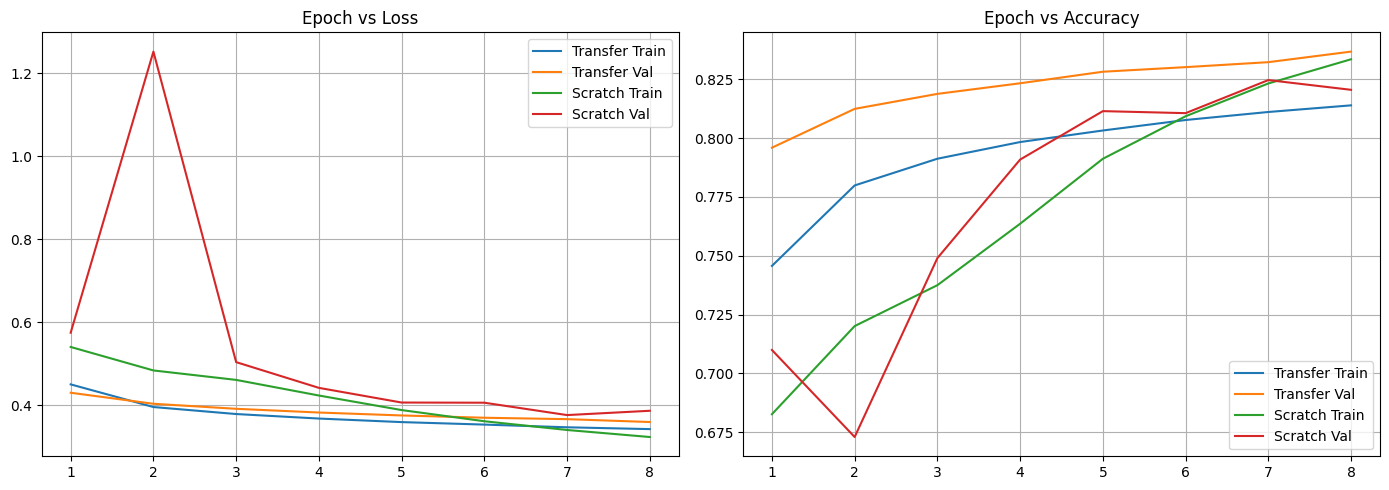

In [5]:
# reverse label map
index_to_cat = {
    0:"short sleeve top",
    1:"trousers",
    2:"shorts",
    3:"long sleeve top",
    4:"skirt"
}

#SECTION 14: TRAINING CURVES COMPARISON
def plot_training_comparison(history_t, history_s):

    fig, axes = plt.subplots(1,2,figsize=(14,5))

    e_t = range(1,len(history_t.history["loss"])+1)
    e_s = range(1,len(history_s.history["loss"])+1)

    # LOSS
    axes[0].plot(e_t,history_t.history["loss"],label="Transfer Train")
    axes[0].plot(e_t,history_t.history["val_loss"],label="Transfer Val")

    axes[0].plot(e_s,history_s.history["loss"],label="Scratch Train")
    axes[0].plot(e_s,history_s.history["val_loss"],label="Scratch Val")

    axes[0].set_title("Epoch vs Loss")
    axes[0].legend()
    axes[0].grid()

    # ACCURACY
    axes[1].plot(e_t,history_t.history["binary_accuracy"],label="Transfer Train")
    axes[1].plot(e_t,history_t.history["val_binary_accuracy"],label="Transfer Val")

    axes[1].plot(e_s,history_s.history["binary_accuracy"],label="Scratch Train")
    axes[1].plot(e_s,history_s.history["val_binary_accuracy"],label="Scratch Val")

    axes[1].set_title("Epoch vs Accuracy")
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.savefig("/kaggle/working/training_comparison.png")
    plt.show()

plot_training_comparison(history_t, history_s)

In [18]:
#SECTION 15: FULL EVALUATION FUNCTION
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score
)

def evaluate_model(model, dataset, model_name="model", threshold=0.5):

    all_preds=[]
    all_labels=[]

    for x,y in dataset:
        p=model.predict(x,verbose=0)
        all_preds.append(p)
        all_labels.append(y.numpy())

    preds=np.vstack(all_preds)
    labels=np.vstack(all_labels)

    binary=(preds>=threshold).astype(int)

    target_names=[str(index_to_cat[i]) for i in range(num_classes)]

    print("\n"+"="*50)
    print(model_name)
    print("="*50)

    print(classification_report(labels,binary,target_names=target_names,zero_division=0))

    macro_f1=f1_score(labels,binary,average="macro",zero_division=0)
    micro_f1=f1_score(labels,binary,average="micro",zero_division=0)

    macro_p=precision_score(labels,binary,average="macro",zero_division=0)
    micro_p=precision_score(labels,binary,average="micro",zero_division=0)

    macro_r=recall_score(labels,binary,average="macro",zero_division=0)
    micro_r=recall_score(labels,binary,average="micro",zero_division=0)

    print(f"Macro F1={macro_f1:.4f}")
    print(f"Micro F1={micro_f1:.4f}")

    # =============================
    # Confusion Matrix
    # =============================

    pred_primary=np.argmax(preds,axis=1)
    true_primary=np.argmax(labels,axis=1)

    cm=confusion_matrix(true_primary,pred_primary)

    plt.figure(figsize=(6,5))
    plt.imshow(cm,cmap="Blues")

    plt.title(model_name+" Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.xticks(range(num_classes),target_names,rotation=45)
    plt.yticks(range(num_classes),target_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j,i,cm[i,j],ha="center",va="center")

    plt.tight_layout()
    plt.show()

    # =============================
    # ROC
    # =============================

    plt.figure(figsize=(6,5))

    for i in range(num_classes):
        fpr,tpr,_=roc_curve(labels[:,i],preds[:,i])
        auc_val=auc(fpr,tpr)
        plt.plot(fpr,tpr,label=f"{target_names[i]} AUC={auc_val:.3f}")

    plt.plot([0,1],[0,1],'k--')
    plt.legend()
    plt.title("ROC Curves")
    plt.show()

    macro_auc=roc_auc_score(labels,preds,average="macro")
    print("Macro ROC AUC:",macro_auc)

    return {
        "macro_f1":macro_f1,
        "micro_f1":micro_f1,
        "macro_p":macro_p,
        "micro_p":micro_p,
        "macro_r":macro_r,
        "micro_r":micro_r,
        "macro_auc":macro_auc,
        "per_class_f1":f1_score(labels,binary,average=None)
    }


TRANSFER MODEL

ResNet50 Transfer
                  precision    recall  f1-score   support

short sleeve top       0.81      0.60      0.69     14111
        trousers       0.92      0.78      0.85     10993
          shorts       0.83      0.63      0.72      7175
 long sleeve top       0.70      0.52      0.60      7240
           skirt       0.68      0.61      0.65      6098

       micro avg       0.81      0.64      0.71     45617
       macro avg       0.79      0.63      0.70     45617
    weighted avg       0.80      0.64      0.71     45617
     samples avg       0.74      0.65      0.67     45617

Macro F1=0.6992
Micro F1=0.7121


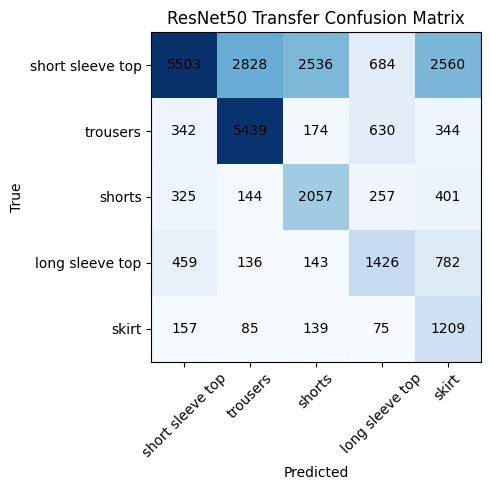

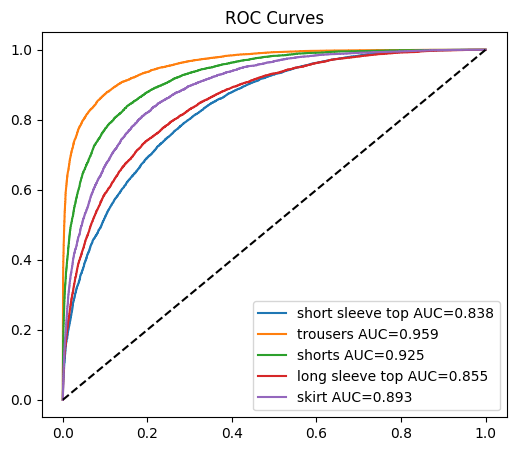

Macro ROC AUC: 0.8940474458129195

SCRATCH MODEL

ResNet50 Scratch
                  precision    recall  f1-score   support

short sleeve top       0.87      0.52      0.65     14111
        trousers       0.92      0.76      0.83     10993
          shorts       0.91      0.48      0.63      7175
 long sleeve top       0.68      0.47      0.55      7240
           skirt       0.56      0.69      0.62      6098

       micro avg       0.79      0.59      0.67     45617
       macro avg       0.79      0.58      0.66     45617
    weighted avg       0.82      0.59      0.67     45617
     samples avg       0.69      0.59      0.62     45617

Macro F1=0.6580
Micro F1=0.6742


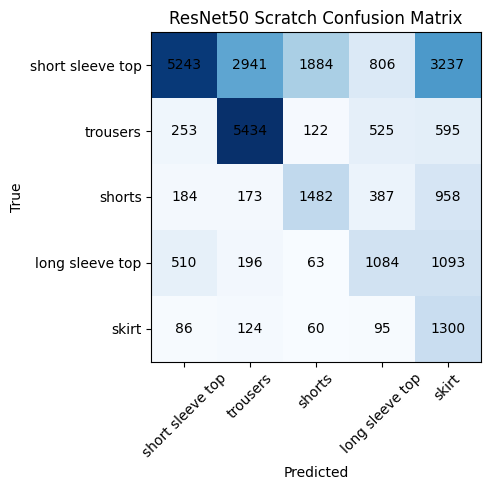

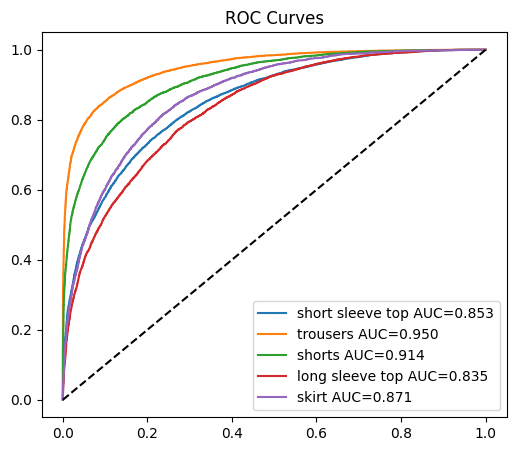

Macro ROC AUC: 0.8846737774501807

Metric                     Transfer        Scratch
macro_f1                     0.6992         0.6580
micro_f1                     0.7121         0.6742
macro_p                      0.7884         0.7877
micro_p                      0.8054         0.7917
macro_r                      0.6298         0.5848
micro_r                      0.6382         0.5871
macro_auc                    0.8940         0.8847


In [19]:
# SECTION 16: FINAL EVALUATION
print("\nTRANSFER MODEL")
results_transfer = evaluate_model(
    model_t, val_ds, "ResNet50 Transfer"
)

print("\nSCRATCH MODEL")
results_scratch = evaluate_model(
    model_s, val_ds, "ResNet50 Scratch"
)

#SECTION 17: COMPARISON TABLE
print("\n"+"="*60)
print(f"{'Metric':<20}{'Transfer':>15}{'Scratch':>15}")
print("="*60)

for m in ["macro_f1","micro_f1","macro_p","micro_p","macro_r","micro_r","macro_auc"]:
    t=results_transfer[m]
    s=results_scratch[m]
    print(f"{m:<20}{t:>15.4f}{s:>15.4f}")

#SECTION 18: SAVE MODELS
model_t.save("/kaggle/working/resnet_transfer_final.h5")
model_s.save("/kaggle/working/resnet_scratch_final.h5")

In [22]:
import shutil

shutil.copy("/kaggle/working/resnet_transfer_final.h5", "/kaggle/working/Resnet50_transfer.h5")
shutil.copy("/kaggle/working/resnet_scratch_final.h5", "/kaggle/working/Resnet50_scratch.h5")

print("Files copied for download")

Files copied for download
